### Prerequisites

In [ ]:
import anndata

import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy.stats import median_abs_deviation

import celltypist
from celltypist import models
import matplotlib.pyplot as plt

import os

import scvi
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

sc.settings.verbosity = 3
sc.logging.print_header()
sc.settings.set_figure_params(dpi=300, facecolor='white', frameon=False,  figsize=[4,4])

### (1) Load and clean data

In [ ]:
#Load and merge data for reference atals – part 1
adata = sc.read_h5ad('../yourpath.h5ad')
adata.obs['source'] = 'Zhou2022'
adata.obs['sample'] = adata.obs['sample_id']
adata.obs['filename'] = adata.obs['sample_id']
adata.obs['patient'] = adata.obs['case']
adata.obs['tissue'] = 'tumor'
adata.obs['disease'] = 'PDAC'
adata.obs['anno'] = adata.obs['annotated']
adata.obs['anno2'] = adata.obs['annotated2']
del adata.uns
del adata.obsm
del adata.obsp
adata.X = adata.layers['counts']
del adata.layers
print(adata)

bdata = sc.read_h5ad('../yourpath.h5ad')
bdata.obs['source'] = 'Werba2023'
bdata.obs['anno2'] = bdata.obs['anno_2']
bdata.obs['tissue'] = bdata.obs['tissue'].replace('pancreas', 'tumor')
del bdata.obsm
print(bdata)
concat_data = sc.concat([adata, bdata], join='outer')
del bdata

adata = sc.read_h5ad('../yourpath.h5ad')
adata.obs['source'] = 'Caronni2023'
adata.obs['anno2'] = adata.obs['anno_2']
adata.obs['tissue'] = adata.obs['tissue'].replace('pancreas', 'tumor')
del adata.obsm
print(adata)
concat_data = sc.concat([concat_data, adata], join='outer')

adata = sc.read_h5ad('../yourpath.h5ad')
adata.obs['source'] = 'Chen2025'
adata.obs['anno2'] = adata.obs['anno_2']
adata.obs['disease'] = 'PDAC'
adata.obs['sample'] = adata.obs['patients'].astype('string').str.cat(adata.obs['tissue'].astype('string'), sep='_')
adata.obs['filename'] = adata.obs['sample']
del adata.obsm
print(adata)
concat_data = sc.concat([concat_data, adata], join='outer')

In [ ]:
concat_data = concat_data[concat_data.obs['biopsy_type'] != "Peripheral Blood"]
concat_data = concat_data[concat_data.obs['tissue'] != "PBMC"]
concat_data = concat_data[concat_data.obs['tissue'] != "liver"]
concat_data.obs['patient'] = concat_data.obs['patient'].astype(str)
concat_data.write('../yourpath/1_1_atlas_part1.h5ad')

In [ ]:
#Load and merge data for reference atlas – part 2
adata = sc.read_h5ad('../yourpath.h5ad')
print(adata)
del adata.obsm
bdata = sc.read_h5ad('../yourpath.h5ad')
bdata = bdata[bdata.obs['disease'] == 'healthy']
print(bdata)
del bdata.obsm
concat_data = sc.concat([adata, bdata], join='outer')
del adata
del bdata
concat_data

In [ ]:
concat_data = concat_data[concat_data.obs['tissue'].isin(['pancreas', 'tumor', 'adjacent normal'])]
concat_data
concat_data.write('../25-09-21_MSC027_CF_PDAC.atlas/results/250921.atlas/1_1_atlas_part2.h5ad')

In [ ]:
#Load and merge data for reference atlas 
adata = sc.read_h5ad('../25-09-21_MSC027_CF_PDAC.atlas/results/250921.atlas/1_1_atlas_part1.h5ad')
print(adata)
bdata = sc.read_h5ad('../25-09-21_MSC027_CF_PDAC.atlas/results/250921.atlas/1_1_atlas_part2.h5ad')
print(bdata)
concat_data = sc.concat([adata, bdata], join='outer')
del bdata
del adata

concat_data.var_names_make_unique()
concat_data.obs_names_make_unique()
sc.pp.filter_genes(concat_data, min_cells = 50)

In [37]:
concat_data.write('../25-09-21_MSC027_CF_PDAC.atlas/results/250921.atlas/1_3_atlas_all.h5ad')

In [23]:
concat_data = sc.read_h5ad('../25-09-21_MSC027_CF_PDAC.atlas/results/250921.atlas/1_3_atlas_all.h5ad')
concat_data

AnnData object with n_obs × n_vars = 569136 × 31977
    obs: 'sample_id', 'biospecimen', 'case', 'nucleic_acid_source', 'n_genes', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'n_cells', 'pct_cells_kept', 'source_file', 'batch', 'Treatment', 'Site', 'Age', 'Treatment Response', 'n_counts', 'MCM5', 'PCNA', 'TYMS', 'FEN1', 'MCM2', 'MCM4', 'RRM1', 'UNG', 'GINS2', 'MCM6', 'CDCA7', 'DTL', 'PRIM1', 'UHRF1', 'HELLS', 'RFC2', 'RPA2', 'NASP', 'RAD51AP1', 'GMNN', 'WDR76', 'SLBP', 'CCNE2', 'UBR7', 'POLD3', 'MSH2', 'ATAD2', 'RAD51', 'RRM2', 'CDC45', 'CDC6', 'EXO1', 'TIPIN', 'DSCC1', 'BLM', 'CASP8AP2', 'USP1', 'CLSPN', 'POLA1', 'CHAF1B', 'BRIP1', 'E2F8', 'HMGB2', 'CDK1', 'NUSAP1', 

In [24]:
#Harmonization
concat_data.obs['tissue'] = concat_data.obs['tissue'].replace('Adjacent_normal', 'adjacent normal')
concat_data.obs['tissue'] = concat_data.obs['tissue'].replace('Tumor', 'tumor')

concat_data.obs['anno3'] = concat_data.obs['anno2']
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('pDCs', 'pDC')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Megakaryocytes', 'other')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Basophils', 'other')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('B Cells', 'B cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Plasma Cells', 'Plasma cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Mast Cells', 'Mast cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Monocytes (classical)', 'Monocytes')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Monocytes (non-classical)', 'Monocytes')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Macrophages (FOLR2+)', 'Macrophages')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Macrophages (IL1B+)', 'Macrophages')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Macrophages (MARCO+SPP1+)', 'Macrophages')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Macrophages (SPP1+MARCO+)', 'Macrophages')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Macrophages (prolif.)', 'Macrophages')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Ductal Cells', 'Epithelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Ductal cells', 'Epithelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Acinar Cells', 'Epithelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Acinar cells', 'Epithelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Exocrine Cancer Cells', 'Epithelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Basal Cancer Cells', 'Epithelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Classical Cancer Cells', 'Epithelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Cancer cells (basal-like)', 'Epithelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Cancer cells (classical)', 'Epithelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Cancer cells (classical-like)', 'Epithelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Cancer cells (exocrine-like)', 'Epithelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Islet cells', 'Epithelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Islet Cells', 'Epithelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Tuft cells', 'Epithelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Endothelial Cells', 'Endothelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Endothelial cells (arterial)', 'Endothelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Endothelial cells (capillary)', 'Endothelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Endothelial cells (lymphatic)', 'Endothelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Endothelial cells (venous)', 'Endothelial cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Fibroblasts', 'Stromal cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('MyoCAF', 'Stromal cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('ApCAF', 'Stromal cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('iCAF', 'Stromal cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('CAF (epithelial-like)', 'Stromal cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Stromal Cells', 'Stromal cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Schwann Cells', 'Stromal cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Schwann cells', 'Stromal cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Pericytes', 'Stromal cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Smooth Muscle Cells', 'Stromal cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('Smooth muscle cells', 'Stromal cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('cDC1', 'cDC')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('cDC2', 'cDC')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('mregDC', 'cDC')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('GD T Cells', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('gd T cells', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('CD4 T Cells', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('CD4 Tcm', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('CD4 Teff', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('CD4 Tn-like', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('CD4 Tem', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('CD4 Treg', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('CD8 T Cells', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('CD8 Teff', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('CD8 Tem', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('CD8 Tex int', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('CD8 Tex prog', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('CD8 Tex term', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('CD8 Tn-like', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('NK Cells', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('NK cells', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('NK-like T cells', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('T cells (prolif.)', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('T/NK cells', 'NK/T cells')
concat_data.obs['anno3'] = concat_data.obs['anno3'].replace('other', 'Unknown')

In [25]:
concat_data = concat_data[concat_data.obs['anno3'] != "Doublets"]
concat_data.obs['sample'] = concat_data.obs['sample'].astype(str)
concat_data.obs['tissue'] = concat_data.obs['tissue'].astype(str)

In [ ]:
#export metadata
columns_to_keep = [
    'sample_id', 'biospecimen', 'case', 'source_file', 'batch', 'Treatment', 'Site', 'Age', 'Treatment Response',
          'matrisome_poor_survival_score', 'source', 'sample', 'patient', 'tissue', 'disease', 'filename', 'sample_x',
           'sample_y', 'technology', 'age', 'sex', 'stage_at_diagnosis', 'treatment', 'treatment_duration', 'response_RECIST',
     'procedure', 'Moffitt', 'grading', 'biopsy_type', 'TNM', 'patients',  'pTNM', 'stage',
]

if 'filename' in concat_data.obs.columns:
    metadata_df = concat_data.obs[columns_to_keep + ['filename']].drop_duplicates(subset=['filename'])
else:
    print("No 'sample' column found. Ensure there's a way to identify unique samples.")

metadata_df.to_excel('../yourpath/1_atlas.metadata.xlsx', index=False)

In [29]:
concat_data.obs = concat_data.obs[['doublet', 'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes',
                                   'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo',
                                     'total_counts_hb','log1p_total_counts_hb', 'pct_counts_hb', 'outlier', 'mt_outlier', 'anno', 'anno2', 'sample','filename','anno3']]

In [ ]:
md = pd.read_excel('../yourpath/1_atlas.metadata.clean.250924.xlsx')
md['filename'] = md['filename'].astype(str)
concat_data.obs['filename'] = concat_data.obs['filename'].astype(str)
concat_data_index = concat_data.obs.index
merged_df = concat_data.obs.merge(md, how="left", on="filename")
concat_data.obs = merged_df
concat_data.obs.index = concat_data_index
concat_data.obs

In [ ]:
concat_data.obs['source_stage'] = concat_data.obs['source_stage'].astype(str)
concat_data.obs['source_patient_id'] = concat_data.obs['source_patient_id'].astype(str)
concat_data.write('../yourpath/1_4_atlas_clean.h5ad')

### (2) Build reference atlas

In [ ]:
#Annotate reference atlas
adata = sc.read_h5ad(filename='../yourpath/1_4_atlas_clean.h5ad')
adata.layers["counts"] = adata.X.copy()
sc.pp.highly_variable_genes(
    adata,
    flavor="seurat_v3",
    n_top_genes=3000,
    layer="counts",
    batch_key="source",
    subset=True,
)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata

In [ ]:
scvi.model.SCVI.setup_anndata(adata, layer='counts',
                              batch_key='sample',
                              categorical_covariate_keys=['source', 'tissue', 'disease','technology']#,
                              )

In [ ]:
model = scvi.model.SCVI(adata, n_layers=2, n_latent=30)
model.train(accelerator="cpu", devices=1)

In [ ]:
model.save(dir_path='../yourpath')

In [38]:
SCVI_LATENT_KEY = "X_scVI"
adata.obsm[SCVI_LATENT_KEY] = model.get_latent_representation()

In [ ]:
SCANVI_CELLTYPE_KEY = "celltype_scanvi"
adata.obs[SCANVI_CELLTYPE_KEY] = "Unknown"

atlas_mask = ~adata.obs['anno3'].isin(['Unknown', 'NaN'])

adata.obs[SCANVI_CELLTYPE_KEY][atlas_mask] = adata.obs.anno3[
    atlas_mask
].values

In [ ]:
np.unique(adata.obs[SCANVI_CELLTYPE_KEY], return_counts=True)

In [41]:
scanvi_model = scvi.model.SCANVI.from_scvi_model(
    model,
    adata=adata,
    unlabeled_category="Unknown",
    labels_key=SCANVI_CELLTYPE_KEY,
)

In [ ]:
scanvi_model.train(max_epochs=20, n_samples_per_label=100, accelerator="cpu", devices=1)

In [ ]:
model.save(dir_path='../yourpath')

In [44]:
SCANVI_LATENT_KEY = "X_scANVI"
SCANVI_PREDICTION_KEY = "C_scANVI"

adata.obsm[SCANVI_LATENT_KEY] = scanvi_model.get_latent_representation(adata)
adata.obs[SCANVI_PREDICTION_KEY] = scanvi_model.predict(adata)

In [ ]:
sc.pp.neighbors(adata, use_rep='X_scANVI')
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=1)

In [ ]:
cell_type = {
    '0': 'Epithelial cells',
    '1': 'T/NK cells',
    '2': 'T/NK cells',
    '3': 'Stromal cells',
    '4': 'Myeloid cells',
    '5': 'T/NK cells',
    '6': 'B cells',
    '7': 'T/NK cells',
    '8': 'Epithelial cells',
    '9': 'Endothelial cells',
    '10': 'Myeloid cells',
    '11': 'T/NK cells',
    '12': 'Stromal cells',
    '13': 'Epithelial cells',
    '14': 'T/NK cells',
    '15': 'Stromal cells',
    '16': 'Myeloid cells',
    '17': 'Epithelial cells',
    '18': 'Epithelial cells',
    '19': 'Myeloid cells',
    '20': 'Epithelial cells',
    '21': 'Stromal cells',
    '22': 'B cells',
    '23': 'Epithelial cells',
    '24': 'Epithelial cells',
    '25': 'Stromal cells',
    '26': 'B cells',
    '27': 'T/NK cells',
    '28': 'T/NK cells',
    '29': 'Epithelial cells',
    '30': 'Stromal cells',
    '31': 'T/NK cells',
    '32': 'Myeloid cells',
    '33': 'Endothelial cells',
    '34': 'Epithelial cells',
    '35': 'Epithelial cells',
    '36': 'Epithelial cells',
    '37': 'Epithelial cells',
    '38': 'Stromal cells',
    '39': 'Epithelial cells',
    '40': 'Epithelial cells',
}

adata.obs['anno_atlas_coarse'] = adata.obs.leiden.map(cell_type)

In [ ]:
adata_anno = adata.obs['anno_atlas_coarse']
bdata = sc.read_h5ad(filename='../yourdata/1_4_atlas_clean.h5ad')
bdata.obs['anno_atlas_coarse'] = adata_anno
bdata.obsm['X_scANVI'] = adata.obsm['X_scANVI']

In [ ]:
bdata.write('../yourdata/2_2_atlas_anno_coarse.h5ad')

... storing 'anno_atlas_coarse' as categorical


In [ ]:
adata.write('../yourdata/2_1_atlas_anno_coarse_hvg3000.h5ad')

... storing 'anno_atlas_coarse' as categorical


In [101]:
cluster_tissue_matrix = pd.crosstab(bdata.obs['patient_id'], bdata.obs['anno_atlas_coarse'])
cluster_tissue_matrix.sample(n=15)

anno_atlas_coarse,B cells,Endothelial cells,Epithelial cells,Myeloid cells,Stromal cells,T/NK cells
patient_id,,,,,,
19.HTAN.PDAC,162,877,1144,1872,10198,6089
89.Carpenter2023.healthy,12,742,17547,1032,249,59
17.HTAN.PDAC,244,149,117,36,113,876
23.HTAN.PDAC,10,26,450,596,90,240
66.Chen2025.PDAC,135,79,398,323,275,36
86.Steele2020.PDAC,325,22,354,829,322,1352
87.Steele2020.PDAC,392,3,655,169,55,595
38.Werba2023.PDAC,65,148,2250,848,574,907
18.HTAN.PDAC,182,240,1331,1031,1366,3206


### (3) Annotate reference atlas

##### Annotation T/NK cells

In [ ]:
adata_tnk = sc.read_h5ad(filename='../yourdata/2_2_atlas_anno_coarse.h5ad')
adata_tnk = adata_tnk[adata_tnk.obs['anno_atlas_coarse'] == "T/NK cells"]
adata_tnk.layers["counts"] = adata_tnk.X.copy()
sc.pp.normalize_total(adata_tnk, target_sum=1e4)
sc.pp.log1p(adata_tnk)
adata_tnk.raw = adata_tnk
adata_tnk

In [ ]:
sc.pp.neighbors(adata_tnk, use_rep='X_scANVI')
sc.tl.umap(adata_tnk)
sc.tl.leiden(adata_tnk, resolution=1.5)

In [ ]:
cell_type = {
    '0': 'CD8 Teff',
    '1': 'CD4 Tem',
    '2': 'CD8 Tex int',
    '3': 'CD4 Teff',
    '4': 'CD8 Teff',
    '5': 'CD4 Treg',
    '6': 'CD4 Tcm',
    '7': 'NK cells',
    '8': 'CD8 Tem',
    '9': 'CD8 Teff',
    '10': 'CD4 Tcm',
    '11': 'CD4 Treg',
    '12': 'CD4 Teff',
    '13': 'gd T cells',
    '14': 'CD8 Tem',
    '15': 'CD4 Tfh',
    '16': 'CD8 Tex term',
    '17': 'CD8 Tex prog',
    '18': 'CD8 Tem',
    '19': 'gd T cells',
    '20': 'CD8 Teff',
    '21': 'NK-like T cells ',
    '22': 'CD8 Teff',
    '23': 'CD8 Tcm',
    '24': 'CD8 Tcm',
    '25': 'CD4 Tcm',
    '26': 'CD8 Teff',
}
adata_tnk.obs['anno_tnk'] = adata_tnk.obs.leiden.map(cell_type)

In [ ]:
adata_tnk.write('../yourpath/3_atlasSub_anno_tnk.h5ad')

##### Annotation B cells

In [ ]:
adata_b = sc.read_h5ad(filename='../yourpath/2_2_atlas_anno_coarse.h5ad')
adata_b = adata_b[adata_b.obs['anno_atlas_coarse'] == "B cells"]
adata_b.layers["counts"] = adata_b.X.copy()
sc.pp.normalize_total(adata_b, target_sum=1e4)
sc.pp.log1p(adata_b)
adata_b.raw = adata_b
adata_b

In [ ]:
sc.pp.neighbors(adata_b, use_rep='X_scANVI')
sc.tl.umap(adata_b)
sc.tl.leiden(adata_b, resolution=1)

In [64]:
cell_type = {
    '0': 'B cells (memory)',
    '1': 'B cells (naive)',
    '2': 'B cells (memory)',
    '3': 'B cells (naive)',
    '4': 'B cells (naive)',
    '5': 'B cells (memory)',
    '6': 'Doublets', # w T cells
    '7': 'B cells (naive)',
    '8': 'B cells (memory)',
    '9': 'Plasma cells',
    '10': 'Doublets', # w T cells
    '11': 'Doublets', # w T cells
    '12': 'B cells (memory)',
    '13': 'B cells (memory)',
    '14': 'Doublets', # w T cells
    '15': 'B cells (memory)',
    '16': 'Doublets', # w T cells
    '17': 'Plasma cells',
    '18': 'Doublets', # w Epithelial cells
    '19': 'Doublets', # w Epithelial cells
}

adata_b.obs['anno_b'] = adata_b.obs.leiden.map(cell_type)

In [ ]:
sc.pl.heatmap(
    adata_b,
    groupby="anno_b",
    var_names=['CD79A','CD79B','CD19',
               'CD37','CXCR4',
               'IGKC','IGHG1','CD38','JCHAIN','JUN','IGHA1',
               'FCER2','TCL1A','IL4R','IGHD','YBX3','IGHM',
               'NR4A2','CD69','CD83',
               'CD22','MARCKSL1',
               'MS4A1','CR2','CD27','RPS17','RACK1',
               'IL7R','TRAC','CD3D',
               'KRT18','KRT19',
               'LYZ','S100A8','C1QA'

               
               ], 
    swap_axes=True, 
    cmap='Greys'
    , vmax="4"
    )

In [ ]:
sc.tl.rank_genes_groups(adata_b, 'anno_b', method='wilcoxon')
sc.pl.rank_genes_groups(adata_b, n_genes=25, sharey=False)

In [ ]:
adata_b.write('../yourpath/3_atlasSub_anno_b.h5ad')

##### Annotation Myeloid cells

In [ ]:
adata_myeloid = sc.read_h5ad(filename='../yourpath/2_2_atlas_anno_coarse.h5ad')
adata_myeloid = adata_myeloid[adata_myeloid.obs['anno_atlas_coarse'] == "Myeloid cells"]
adata_myeloid.layers["counts"] = adata_myeloid.X.copy()
sc.pp.normalize_total(adata_myeloid, target_sum=1e4)
sc.pp.log1p(adata_myeloid)
adata_myeloid.raw = adata_myeloid
adata_myeloid

In [ ]:
sc.pp.neighbors(adata_myeloid, use_rep='X_scANVI')
sc.tl.umap(adata_myeloid)
sc.tl.leiden(adata_myeloid, resolution=2)

In [204]:
cell_type = {
    '0': 'Macrophages (FOLR2+)',
    '1': 'DC2',
    '2': 'Macrophages (IL1B+)',
    '3': 'Mast cells',
    '4': 'Macrophages (SPP1+MARCO+)',
    '5': 'Mast cells',
    '6': 'Macrophages (SPP1+MARCO+)',
    '7': 'Mast cells',
    '8': 'Neutrophils', #only in Steele
    '9': 'Macrophages (SPP1+MARCO+)',
    '10': 'Monocytes (classical)',
    '11': 'Monocytes (classical)',
    '12': 'Monocytes (classical)',
    '13': 'Monocytes (classical)',
    '14': 'Neutrophils',
    '15': 'Macrophages (IL1B+)',
    '16': 'Macrophages (IL1B+)',
    '17': 'Macrophages (IL1B+)',
    '18': 'Macrophages (prolif.)',
    '19': 'Macrophages (FOLR2+)',
    '20': 'Macrophages (SPP1+MARCO+)',
    '21': 'Doublets',
    '22': 'Monocytes (non-classical)',
    '23': 'DC2',
    '24': 'Macrophages (SPP1+MARCO+)',
    '25': 'Macrophages (FOLR2+)',
    '26': 'Macrophages (IL1B+)',
    '27': 'Macrophages (FOLR2+)',
    '28': 'Macrophages (IL1B+)',
    '29': 'Macrophages (IL1B+)',
    '30': 'Neutrophils',
    '31': 'pDC',
    '32': 'Macrophages (FOLR2+)',
    '33': 'Mast cells',
    '34': 'DC1',
    '35': 'Doublets', #w Monocytes
    '36': 'mregDC',
    '37': 'Macrophages (FOLR2+)',
    '38': 'Mast cells',
    '39': 'Mast cells',
    '40': 'Macrophages (SPP1+MARCO+)',
    '41': 'Doublets', #w Erythrocytes
    '42': 'Macrophages (SPP1+MARCO+)',
    '43': 'Mast cells',
}
adata_myeloid.obs['anno_myeloid'] = adata_myeloid.obs.leiden.map(cell_type)

In [ ]:
anno_genes = [
    ### Myeloid cells
        'FCER1G','HLA-DRA', #pan-myeloid
        "GATA2", "FCER1A", # Basophils
        "BATF3","C1orf54","CADM1", "CLEC9A", "IRF8",'XCR1','WDFY4', #DC1
        "CD1C",'CD1E',"CLEC10A","FCER1A","CD209", "HLA-DMB",  #DC2 
        'CCR7','LAMP3','BIRC3',"MARCKSL1","CCL17", "CCL22","IL4I1", "SOCS2", "RELB", #mregDC
        'GZMB','IL3RA','JCHAIN','IRF7', #pDC               
        'MS4A2','SLC18A2','RGS13',"CPA3", #Mast cells
        'S100A8','S100A9','VCAN','CLEC4E','FCN1','S100A12', #Classical monocytes
        "FCGR3A",'LST1', #non-classical monocytes
        'CXCR2','CXCL8','IL8','MPO',"GRINA","MMP8", "MMP9", "CD177", "WFDC21", #Neutrophils
        'SPP1','HAMP',"GPR183",'LYVE1',"FOLR2",'SELENOP','F13A1','IL1B','GPNMB','SPP1','MARCO',"TREM2",'A2M','CD9','FBP1','THBS1','MMP9',  #mo-macs
        "C1QA",'C1QB',"CD68",'CD63','CTSB','APOE', #Macrophages
    ### Cycling
        'MKI67','TOP2A',
]
anno_genes = [gene for gene in anno_genes if gene in adata_myeloid.var.index]

In [ ]:
sc.pl.heatmap(adata_myeloid, anno_genes, groupby='anno_myeloid', swap_axes=True, 
                          cmap='Greys'
                          , vmax="5",
                          show_gene_labels=True
              )

In [ ]:
adata_myeloid.write('../yourpath/3_atlasSub_anno_myeloid.h5ad')

##### Annotation Endothelial cells

In [ ]:
adata_endo = sc.read_h5ad(filename='../yourpath/2_2_atlas_anno_coarse.h5ad')
adata_endo = adata_endo[adata_endo.obs['anno_atlas_coarse'] == "Endothelial cells"]
adata_endo.layers["counts"] = adata_endo.X.copy()
sc.pp.normalize_total(adata_endo, target_sum=1e4)
sc.pp.log1p(adata_endo)
adata_endo.raw = adata_endo
adata_endo

In [ ]:
sc.pp.neighbors(adata_endo, use_rep='X_scANVI')
sc.tl.umap(adata_endo)
sc.tl.leiden(adata_endo, resolution=0.5)

In [34]:
cell_type = {'0':'Endothelial cells (venous)',
 '1':'Endothelial cells (capillary)',
 '2':'Doublets', # w Pericytes
 '3':'Endothelial cells (angiogenic)',
 '4':'Endothelial cells (arterial)',
 '5':'Doublets', #w Acinar
 '6':'Doublets', #w Cancer cells
 '7':'Endothelial cells (lymphatic)',
 '8':'Doublets', # w T cells
 '9':'Doublets', # w Erythrocytes
}
adata_endo.obs['anno_endo'] = adata_endo.obs.leiden.map(cell_type)

In [ ]:
adata_endo.write('../yourpath/3_atlasSub_anno_endo.h5ad')

##### Annotation Epithelial cells

see other script

##### Annotation Stromal cells

In [ ]:
adata_stroma = sc.read_h5ad(filename='../yourpath/2_2_atlas_anno_coarse.h5ad')
adata_stroma = adata_stroma[adata_stroma.obs['anno_atlas_coarse'].isin(['Stromal cells'])]
adata_stroma.layers["counts"] = adata_stroma.X.copy()
sc.pp.normalize_total(adata_stroma, target_sum=1e4)
sc.pp.log1p(adata_stroma)
adata_stroma.raw = adata_stroma
adata_stroma

In [ ]:
sc.pp.neighbors(adata_stroma, use_rep='X_scANVI')
sc.tl.umap(adata_stroma)
sc.tl.leiden(adata_stroma, resolution=1)

In [127]:
cell_type = {
    '0': 'MyoCAF',
    '1': 'Fibroblasts',
    '2': 'Smooth muscle cells',
    '3': 'Pericytes',
    '4': 'MyoCAF',
    '5': 'Fibroblasts',
    '6': 'Fibroblasts',
    '7': 'iCAF',
    '8': 'Fibroblasts', 
    '9': 'Smooth muscle cells',
    '10': 'Doublets', # w Epithelial cells
    '11': 'Schwann cells',
    '12': 'ApCAF',
    '13': 'iCAF',
    '14': 'iCAF',
    '15': 'Fibroblasts',
    '16': 'Fibroblasts',
    '17': 'Perivascular fibroblasts',
    '18': 'Doublets', # w Epithelial cells
    '19': 'Smooth muscle cells',
    '20': 'MyoCAF',
    '21': 'Cancer cells (classical)',
    '22': 'Doublets', # w Epithelial cells
    '23': 'Acinar cells',
}
adata_stroma.obs['anno_stroma'] = adata_stroma.obs.leiden.map(cell_type)

In [ ]:
sc.tl.rank_genes_groups(adata_stroma, 'anno_stroma', method='wilcoxon')
sc.pl.rank_genes_groups(adata_stroma, n_genes=25, sharey=False)

In [ ]:
adata_stroma.write('../yourpath/3_atlasSub_anno_stroma.h5ad')

### Merge annotations

In [ ]:
adata_tnk = sc.read_h5ad(filename='../yourpath/3_atlasSub_anno_tnk.h5ad')
adata_b = sc.read_h5ad(filename='../yourpath/3_atlasSub_anno_b.h5ad')
adata_myeloid = sc.read_h5ad(filename='../yourpath/3_atlasSub_anno_myeloid.h5ad')
adata_endo = sc.read_h5ad(filename='../yourpath/3_atlasSub_anno_endo.h5ad')
adata_epithelial = sc.read_h5ad(filename='../yourpath/3_atlasSub_anno_epithelial.h5ad')
adata_stroma = sc.read_h5ad(filename='../yourpath/3_atlasSub_anno_stroma.h5ad')

barcode_df1 = adata_tnk.obs.copy()
barcode_df1['anno_sub'] = barcode_df1['anno_tnk']
barcode_df1 = barcode_df1[['anno_sub']]
barcode_df2 = adata_b.obs.copy()
barcode_df2['anno_sub'] = barcode_df2['anno_b']
barcode_df2 = barcode_df2[['anno_sub']]
barcode_df3 = adata_myeloid.obs.copy()
barcode_df3['anno_sub'] = barcode_df3['anno_myeloid']
barcode_df3 = barcode_df3[['anno_sub']]
barcode_df4 = adata_endo.obs.copy()
barcode_df4['anno_sub'] = barcode_df4['anno_endo']
barcode_df4 = barcode_df4[['anno_sub']]
barcode_df5 = adata_epithelial.obs.copy()
barcode_df5['anno_sub'] = barcode_df5['anno_epithelial']
barcode_df5 = barcode_df5[['anno_sub']]
barcode_df6 = adata_stroma.obs.copy()
barcode_df6['anno_sub'] = barcode_df6['anno_stroma']
barcode_df6 = barcode_df6[['anno_sub']]

merged_barcode_df = pd.concat([barcode_df1, barcode_df2, barcode_df3, barcode_df4, barcode_df5, barcode_df6])
merged_barcode_df

In [ ]:
adata = sc.read_h5ad(filename='../yourpath/2_2_atlas_anno_coarse.h5ad')
merged_barcode_df.index.name = "Barcode"  
merged_dataset = adata.obs.merge(merged_barcode_df, left_index=True, right_index=True, how="left")
adata.obs = merged_dataset
adata.obs

In [ ]:
adata = adata[adata.obs['anno_sub'] != 'Doublets']
adata

In [ ]:
adata.write_h5ad('../yourpath/4_atlas_anno.h5ad')

... storing 'anno_sub' as categorical


In [ ]:
### Add Treatment metadata
md = pd.read_excel('../yourpath.xlsx')
md['sample_id'] = md['sample_id'].astype(str)
md = md[['sample_id','treatment']]
adata = sc.read_h5ad('../yourpath/4_atlas_anno.h5ad')
adata_index = adata.obs.index
merged_df = adata.obs.merge(md, how="left", on="sample_id")
adata.obs = merged_df
adata.obs.index = adata_index
adata.obs['treatment'] = adata.obs['treatment_y']
del adata.obs['treatment_y']
del adata.obs['treatment_x']

adata.write_h5ad('../yourpath/4_atlas_anno.h5ad')

... storing 'sample_id' as categorical
... storing 'treatment' as categorical


In [ ]:
#Normalize
adata = sc.read_h5ad('../yourpath/4_atlas_anno.h5ad')
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata
sc.pp.neighbors(adata, use_rep='X_scANVI')
sc.tl.umap(adata)
adata.write_h5ad('../yourpath/4_atlas_anno_norm.h5ad')

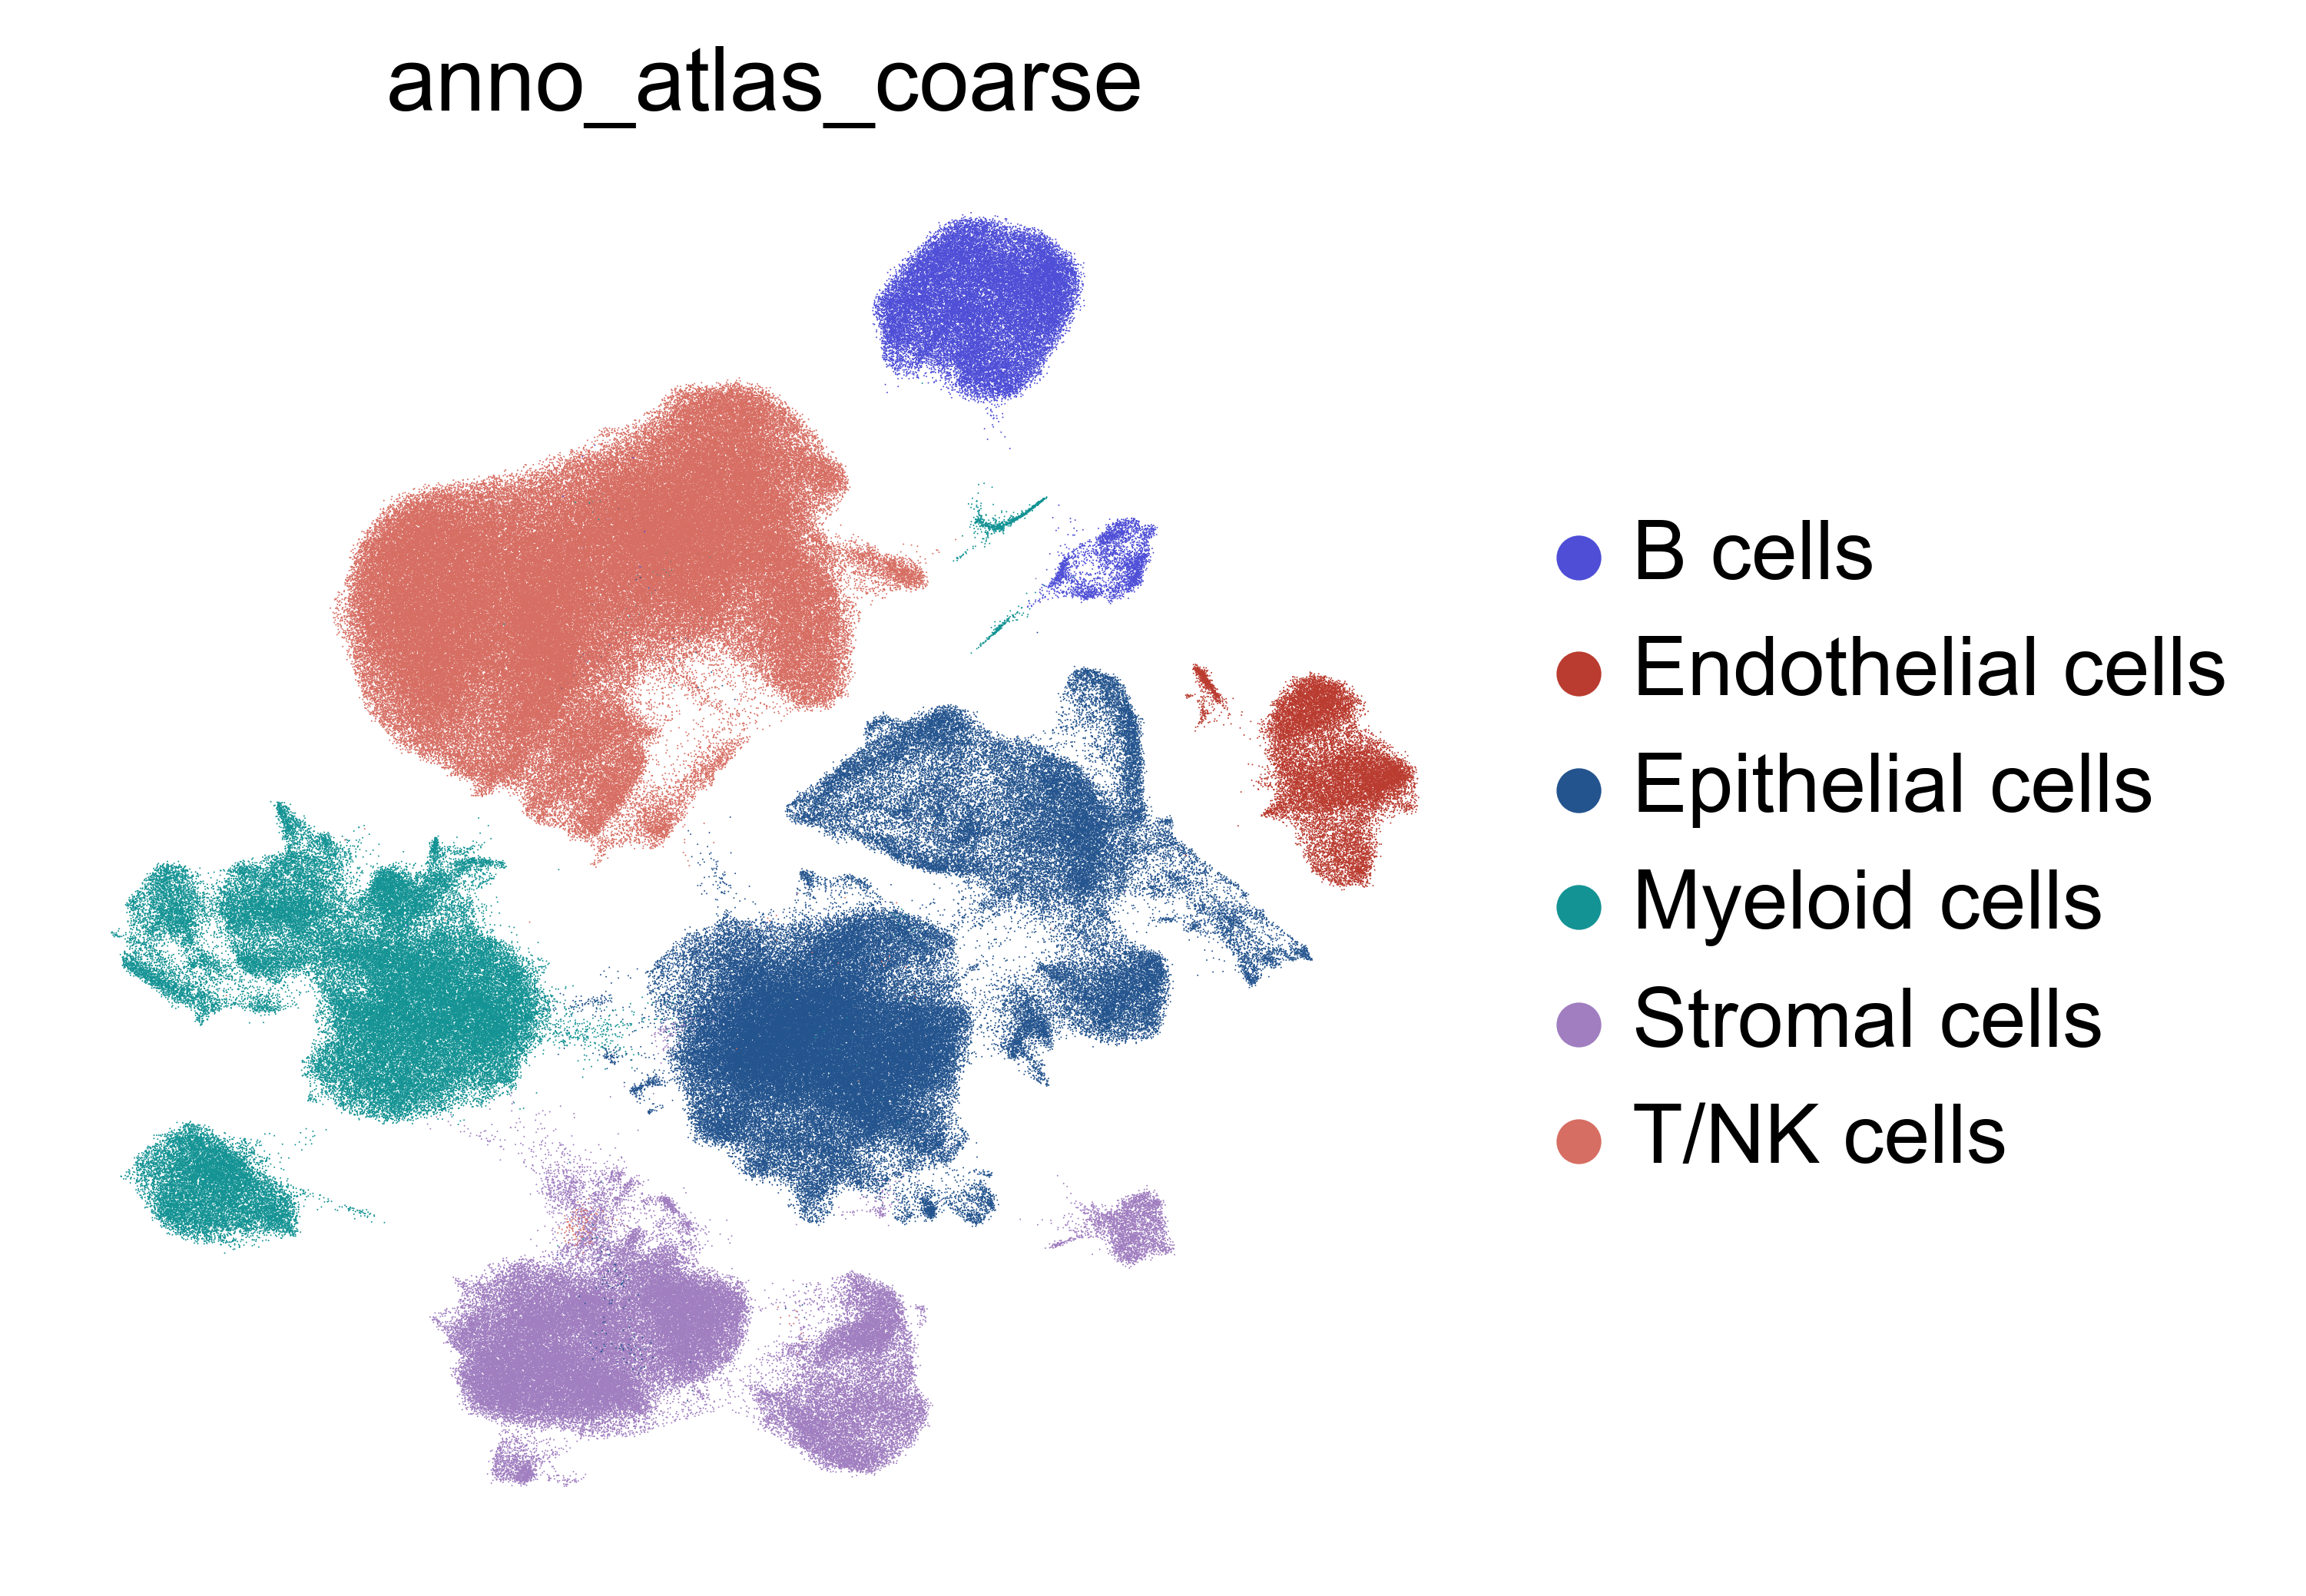

In [ ]:
sc.pl.umap(adata, color=['anno_atlas_coarse'])